In [1]:
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt
import pandas as pd
import sys

sys.path.append('//allen/aics/assay-dev/users/Erin/git-repos/cellsmap/cellsmap/analyses')

In [2]:
exp_var = np.load('../data/MAE_ExpVar.npy')
pcs = np.load('../data/MAE_PCs.npy')

num_modes_95 = np.where(np.cumsum(exp_var) > 0.95)[0].min()
print("Number of modes to explain 95% of variance: ", num_modes_95)
X_t = np.load('../data/MAE_95pctVarPCs_all.npy') # preprocessed data: num_loc * num_timepoints * num_modes_95 array

X_t_high = np.load('../data/MAE_95pctVarPCs_highFlow.npy')
X_t_low = np.load('../data/MAE_95pctVarPCs_lowFlow.npy')

num_loc = X_t.shape[0]
num_t = X_t.shape[1]
t_change = (24*60 - 25)//5 # time point (frame number) at which to change from high to low flow occurs (25 minutes before 24 hours)

Number of modes to explain 95% of variance:  12


## Load MAE data

Masked autoencoder dataset info:
- columns 0-255 are the latent features of the contrastive model
- location gives a unique id for each 512x512 patch of the image (stitched FOVs) that is consistent across time (54 locations)
- time is the index into the movie (0 to 576, units 5 minutes)

Original endothelial cell dataset info (from `cellsmap/cellsmap/data_config.yaml`):
- flow rate of 20 dyn/cm^2 from 0 to 24 hours
- flow rate of 6 dyn/cm^2 from 24 to 48 hours
- time interval between images (data points) is 5 minutes

Data loaded and preprocessed in `utils/mae_feats_init.py`.

In [3]:
exp_var = np.load('../data/MAE_ExpVar.npy')
pcs = np.load('../data/MAE_PCs.npy')

num_modes_95 = np.where(np.cumsum(exp_var) > 0.95)[0].min()
print("Number of modes to explain 95% of variance: ", num_modes_95)

Number of modes to explain 95% of variance:  12


In [4]:
X_t = np.load('../data/MAE_95pctVarPCs_all.npy') # preprocessed data: num_loc * num_timepoints * num_modes_95 array

X_t_high = np.load('../data/MAE_95pctVarPCs_highFlow.npy')
X_t_low = np.load('../data/MAE_95pctVarPCs_lowFlow.npy')

num_loc = X_t.shape[0]
num_t = X_t.shape[1]
t_change = (24*60 - 25)//5 # time point (frame number) at which to change from high to low flow occurs (25 minutes before 24 hours)

Text(0, 0.5, 'PC1')

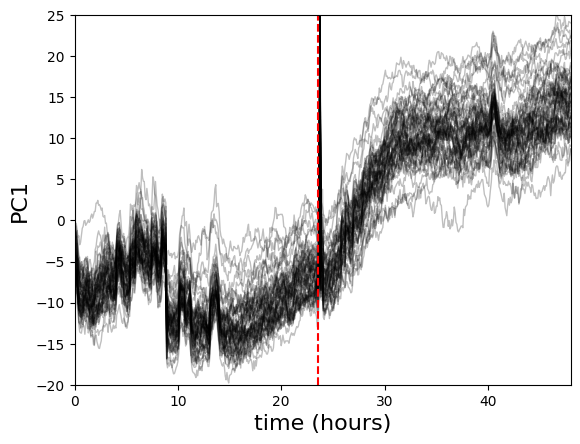

In [5]:
# plot top PCA mode vs time for each location at high flow
for i in range(num_loc):
    plt.plot(5*np.arange(num_t)/60,X_t[i,:,0],'k-',alpha=0.25,linewidth=1)
plt.xlim([0,(num_t)*5//60])
plt.ylim([-20,25])
plt.vlines(5*t_change/60,-20,25,color='r',linestyles='dashed')
#plt.vlines(530/60,-20,25,color='b',linestyles='dashed')
plt.xlabel("time (hours)", fontsize=16)
plt.ylabel("PC1", fontsize=16)

Text(0, 0.5, 'PC2')

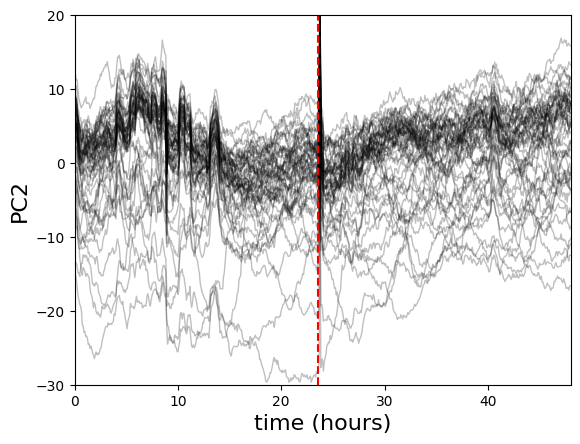

In [6]:
# plot 2nd PCA mode vs time for each location at high flow
for i in range(num_loc):
    plt.plot(5*np.arange(num_t)/60,X_t[i,:,1],'k-',alpha=0.25,linewidth=1)
plt.xlim([0,(num_t)*5//60])
plt.ylim([-30,20])
plt.vlines(5*t_change/60,-30,20,color='r',linestyles='dashed')
#plt.vlines(530/60,-20,25,color='b',linestyles='dashed')
plt.xlabel("time (hours)", fontsize=16)
plt.ylabel("PC2", fontsize=16)

### Find trajectories that spike at flow transition time

In [7]:
which_spike = []
for i in range(num_loc):
    if np.any(X_t[i,t_change-5:t_change+5,0] > 10):
        which_spike.append(i)

In [8]:
len(which_spike) == num_loc

True

In [9]:
np.unique([np.argmax(X_t[i,:,0]) for i in range(num_loc)])

array([285])

In [10]:
t_spike = 285

### Investigate image crops at "spike time"

In [11]:
from skimage import io
import imageio

In [ ]:
path_to_mae = "//allen/aics/assay-dev/users/Benji/cellsmap/results/mae_with_crops/predictions.csv"
df = pd.read_csv(path_to_mae)
df = df.sort_values(by=['time'])

# add crop location index as metadata
crop_paths = df['crop_path'].values.tolist()
loc_idx = []
for path in crop_paths:
    loc_idx.append(int(path.split("_")[-1].split(".")[0]))

# add crop index to dataframe
df['loc_idx'] = loc_idx
df = df.sort_values(by=['loc_idx','time'])

/tmp/ipykernel_28706/3317333914.py:17: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread('figs/crops_'+str(t)+'.png')


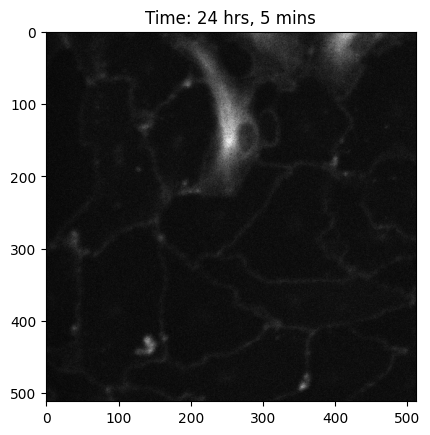

In [ ]:
images=[]

# get data frame for all image crops at time of spike +/- 10 minutes
img_idx = 30
for t in range(t_spike-4,t_spike+4+1):
    crop_path = df[(df['loc_idx']==img_idx) & (df['time']==t)]['crop_path'].values[0]
    img = io.imread(crop_path)
    plt.imshow(img,cmap='gray')
    hrs = t*5//60
    mins = np.round((t*5/60-t*5//60)*60).astype(int)
    color = 'k'
    if t == t_spike:
        color = 'r'
    plt.title("Time: "+str(hrs)+" hrs, "+str(mins)+" mins",color=color)
    plt.savefig('figs/crops_'+str(t)+'.png')

    img = imageio.imread('figs/crops_'+str(t)+'.png')
    images.append(img)

imageio.mimsave('crops.gif', images,fps=1.5, loop=0)

/tmp/ipykernel_28706/122753385.py:31: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  myplot = imageio.imread('figs/hists_'+str(t)+'.png')


124211.72222222222


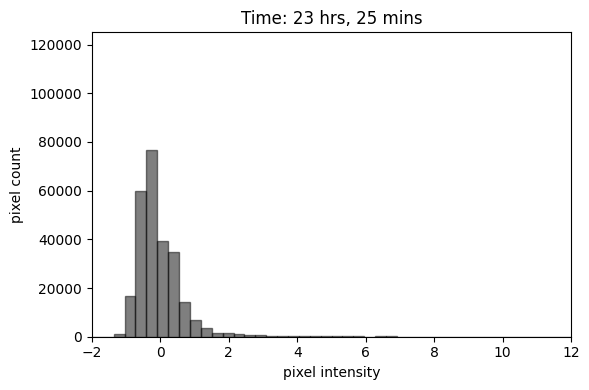

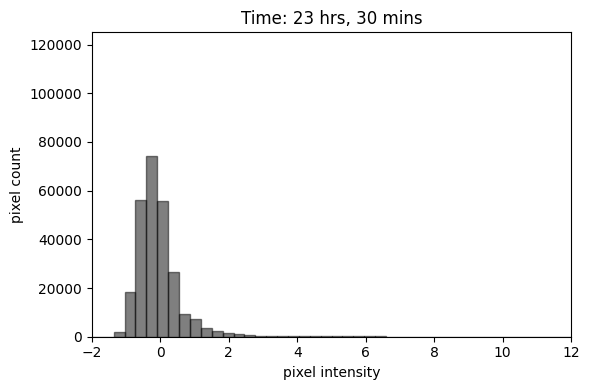

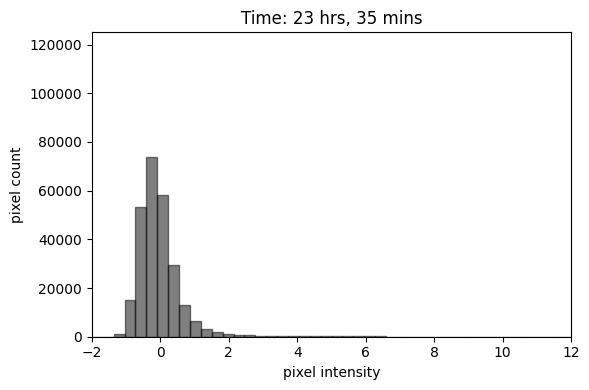

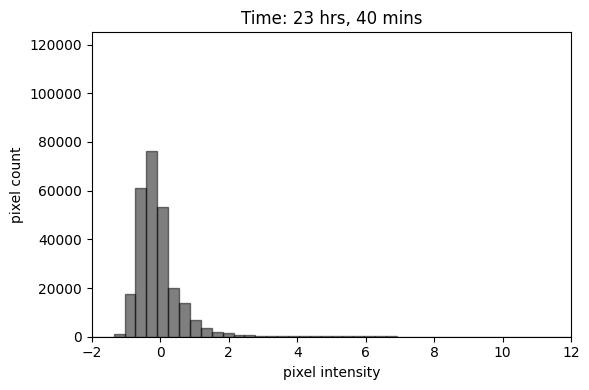

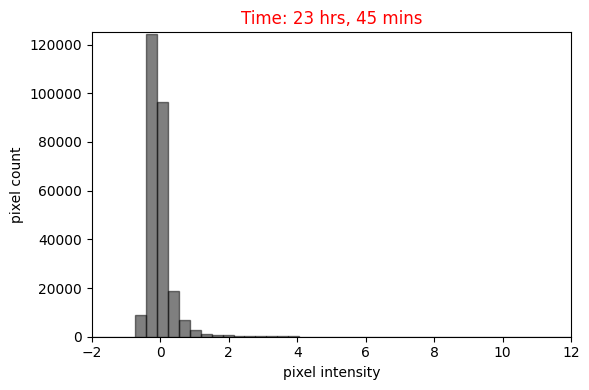

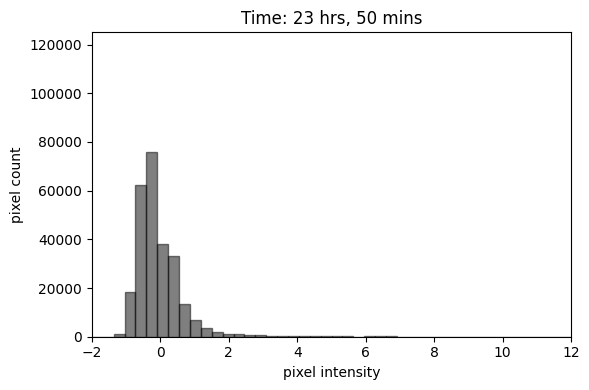

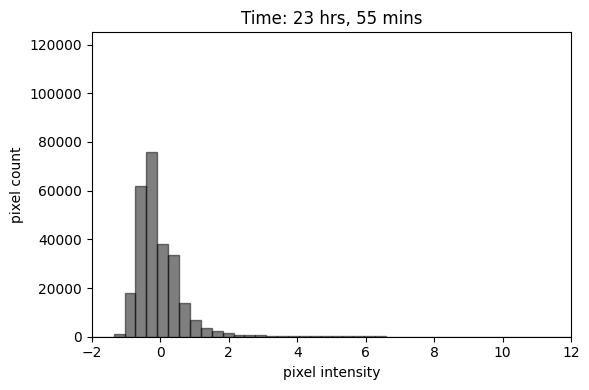

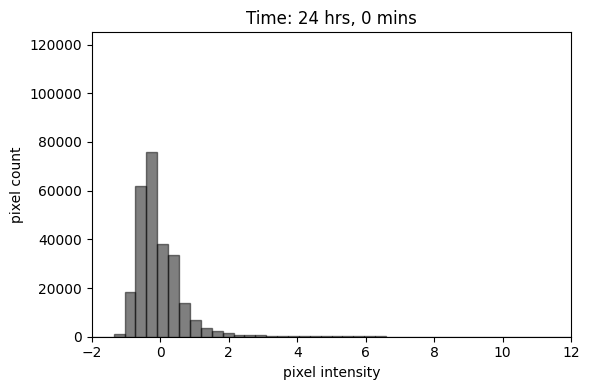

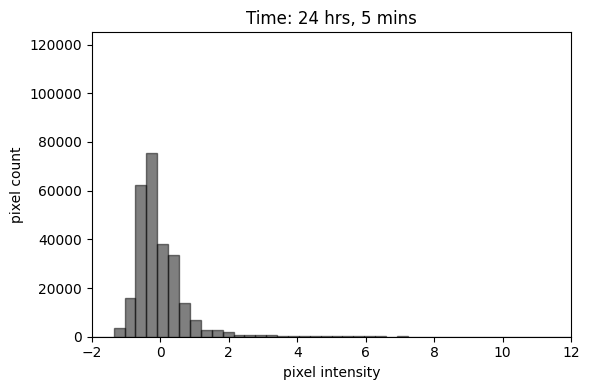

In [ ]:
# plot histogram of intensity values for this crop
# fig = plt.figure(figsize=(6,4))
# ax = plt.gca()
n = 9
xbins = np.linspace(-2,12,45)
xcenters = (xbins[:-1]+xbins[1:])/2
dx = xbins[1]-xbins[0]

images = []
for t in range(t_spike-n//2,t_spike+n//2+1):
    hists = []
    for img_idx in range(num_loc):    
        crop_path = df[(df['loc_idx']==img_idx) & (df['time']==t)]['crop_path'].values[0]
        img = io.imread(crop_path)
        hists.append(np.histogram(img.flatten(),bins=xbins)[0])
    fig = plt.figure(figsize=(6,4))

    plt.bar(xcenters,sum(hists)/num_loc,width=dx,alpha=0.5,linewidth=1,color='k',edgecolor='k')
    plt.xlim([-2,12])
    plt.ylim([0,125000])
    plt.xlabel('pixel intensity')
    plt.ylabel('pixel count')
    color = 'k'
    if t == t_spike:
        color = 'r'
        print(max(sum(hists)/num_loc))
    plt.title("Time: "+str(t*5//60)+" hrs, "+str(np.round((t*5/60-t*5//60)*60).astype(int))+" mins",color=color)
    plt.tight_layout()
    plt.savefig('figs/hists_'+str(t)+'.png')

    myplot = imageio.imread('figs/hists_'+str(t)+'.png')
    images.append(myplot)

imageio.mimsave('hists.gif', images,fps=1.5, loop=0)

Text(0, 0.5, 'time (mins)')

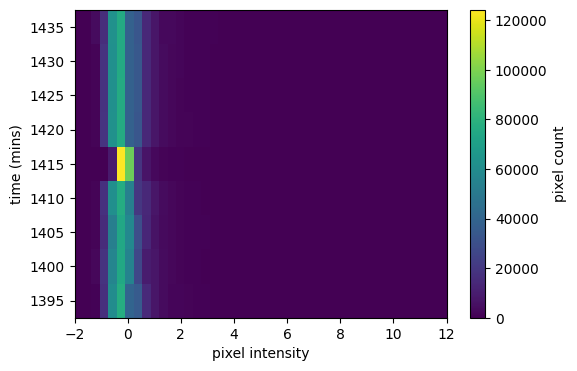

In [ ]:
# plot histogram of intensity values for this crop
fig = plt.figure(figsize=(6,4))
ax = plt.gca()
n = 9
hists = []
xbins = np.linspace(-2,12,45)

for img_idx in range(num_loc):
    hists_img = []
    for t in range(t_spike-n//2,t_spike+n//2+1):
        crop_path = df[(df['loc_idx']==img_idx) & (df['time']==t)]['crop_path'].values[0]
        img = io.imread(crop_path)
        hists_img.append(np.histogram(img.flatten(),bins=xbins)[0])
    hists.append(np.array(hists_img))

avg_hists = sum(hists)/num_loc    

plt.pcolormesh(xbins,np.arange(t_change-n//2,t_change+n//2+2),avg_hists, cmap='viridis')
plt.colorbar(label='pixel count')
plt.yticks(ticks=0.5+np.arange(t_change-n//2,t_change+n//2+2),labels=5*np.arange(t_change-n//2,t_change+n//2+2))
plt.ylim([t_change-n//2,t_change+n//2+1])
plt.xlabel('pixel intensity')
plt.ylabel('time (mins)')

## Bifurcation analysis ([Freedman <i>et al.</i> 2023)](https://doi.org/10.1242/dev.201280))

From "Analysis Pipeline" section of paper:
1. Obtain highly sampled temporal data.
2. Bin the data along the temporal axis.
3. Compute the largest eigenvalue of the covariance matrix ($\omega_1$) in each bin (e.g. using an off-the-shelf PCA function).
4. Evaluate whether a bifurcation occurs by comparing $\omega_1$ with a suitable null (see [Appendix S1](https://journals.biologists.com/Toolbox/DownloadCombinedArticleAndSupplmentPdf?resourceId=312613&multimediaId=2900265&pdfUrl=%2Fcob%2Fcontent_public%2Fjournal%2Fdev%2F150%2F11%2F10.1242_dev.201280%2F2%2Fdev201280.pdf), section 4): spike indicates a one-to-one bifurcation; steady increase indicates a one-to-many bifurcation.
5. If a bifurcation is detected (e.g. at $\tau_c$), compute and examine the principal covariance eigenvector at $\tau$, as it reflects mechanistic aspects of the underlying dynamical system.

In [ ]:
bin_width=6 # number of timepoints to bin together
bins = np.arange(0,num_t,bin_width)
N = len(bins)-1
centers = (bins[:-1]+bins[1:])/2

In [ ]:
omega1 = np.zeros(N)
v1 = np.zeros((num_modes_95,N))

n_s = 50 # null sampling
omega1_null = np.zeros((N,n_s))

for i in range(N):
    data_binned = X_t[:,bins[i]:bins[i+1],:].reshape(-1,num_modes_95)
    C = np.cov(data_binned,rowvar=False)
    omega, v = np.linalg.eigh(C)
    omega1[i] = omega[-1]
    v1[:,i] = v[:,-1]

    for j in range(n_s):
        null_mat = np.zeros((num_loc,num_modes_95))
        for jj in range(num_modes_95):
            null_mat[:,jj] = np.random.choice(data_binned[:,jj],size=num_loc)
        C_null = np.cov(null_mat,rowvar=False)
        omega1_null[i,j] = np.linalg.eigvalsh(C_null)[-1]
    

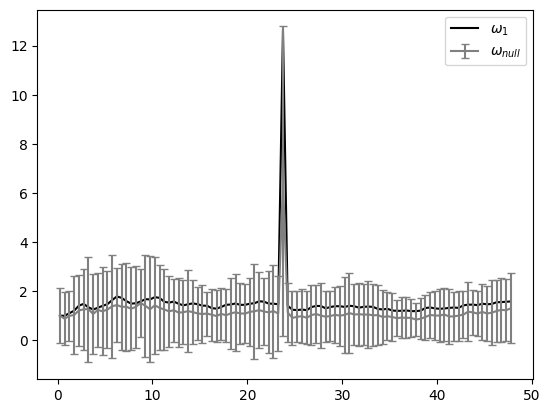

In [ ]:
plt.plot(5*centers/60,omega1/omega1[0],'k-',label='$\\omega_1$')
plt.errorbar(5*centers/60,omega1_null.mean(axis=-1)/omega1_null.mean(axis=-1)[0],
             yerr=omega1_null.std(axis=-1)/np.sqrt(n_s),
             capsize=3,color='gray',ecolor='gray',label='$\omega_{null}$')
plt.legend()

In [ ]:
idx_max = omega1.argmax()
max_evec = v1[:,idx_max]
xbins = np.linspace(-12,22,25)
proj_traj_dist = []
for i in range(N):
    data_binned = X_t[:,bins[i]:bins[i+1],:]
    proj_data = [np.dot(data_binned[ii,jj,:],max_evec) for ii in range(num_loc) for jj in range(bin_width)]
    proj_traj_dist.append(np.histogram(np.array(proj_data), xbins, density=True)[0])

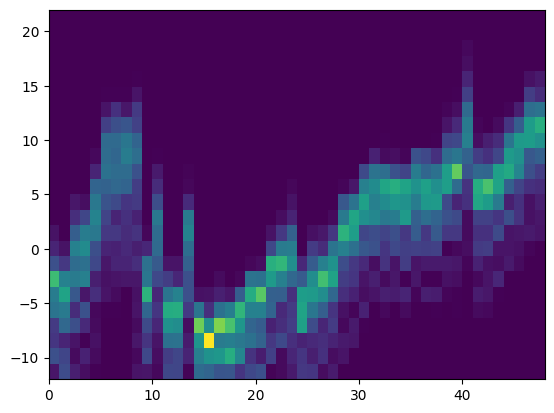

In [ ]:
plt.pcolormesh(5*bins//60,xbins,np.array(proj_traj_dist).T, cmap='viridis')

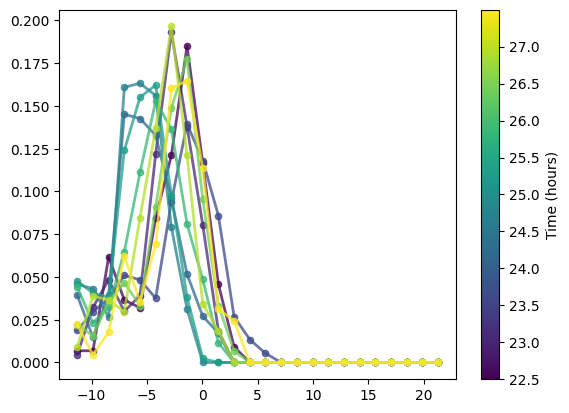

In [ ]:
import matplotlib as mpl

n = 10
colors = plt.cm.viridis(np.linspace(0,1,n))

c = np.arange(1, n + 1)

norm = mpl.colors.Normalize(vmin=1, vmax=n+1)
cmap = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.colormaps['viridis'])
cmap.set_array([])

fig, ax = plt.subplots(dpi=100)
for i in range(n):
    ax.plot(0.5*(xbins[1:]+xbins[:-1]),proj_traj_dist[N//2-3+i], c=colors[i],marker='.',alpha=0.75,linewidth=2,markersize=9)
cbar = fig.colorbar(cmap, ticks=c,ax=ax,label='Time (hours)')
cbar.ax.set_yticklabels(5*np.arange(bins[N//2-3],bins[N//2-3+n],bin_width)/60)
plt.show()